In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("winequality.csv")

In [3]:
df.shape

(1599, 12)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [10]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [15]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [11]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


# Columns realtion with the target variable
1. fixed acidity: makes wine crisp,sour taste; should be moderate.
2. volatile acidity: acid that can evaporate from wine; should be low/moderate.
3.  citric acid: not low or high
4. residual sugar: moderate can contribute to balance.
5. chlorides: high chloride means lower quality.
6. free sulfur dioxide : moderate amount only
7. total sulfur dioxide : total so2 >= free so2.
8. density : can be influenced by alohol, sugar and other dissolved substances.
9. pH: wine is generally acidic in nature. but pH should not be too high or too low.
10. sulphates: range- 0.33 to 2.00
11. alcohol : range- 8.4 to  14.9, higher alc = higher quality ratings.
12. WINE QUALITY: range- 3 to 8; high number means higher quality wine. 

In [4]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [5]:
df.duplicated().value_counts()

False    1359
True      240
Name: count, dtype: int64

240 = duplicate values

In [6]:
duplicate_percentage = (df.duplicated().sum() / len(df)) * 100

print(duplicate_percentage)

15.0093808630394


Deleting Duplicates

In [7]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [8]:
df.shape

(1359, 12)

In [9]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,5.623252
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065,0.823578
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


# Insight:
the dataset went from having 1599 to having 1359 records after removing the duplicate rows 

In [10]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (df < lower_bound) | (df > upper_bound)

outlier_counts = outliers.sum()

print(outlier_counts)

fixed acidity            41
volatile acidity         19
citric acid               1
residual sugar          126
chlorides                87
free sulfur dioxide      26
total sulfur dioxide     45
density                  35
pH                       28
sulphates                55
alcohol                  12
quality                  27
dtype: int64


# Outliners Detection

In [11]:
df[df["residual sugar"] > upper_bound["residual sugar"]]["residual sugar"]

9        6.1
14       3.8
15       3.9
18       4.4
33      10.7
        ... 
1552     3.7
1558     6.7
1574    13.9
1577     5.1
1589     7.8
Name: residual sugar, Length: 126, dtype: float64

In [12]:
print("Lower bound:", lower_bound["residual sugar"])
print("Upper bound:", upper_bound["residual sugar"])

Lower bound: 0.8499999999999996
Upper bound: 3.6500000000000004


# Insight for Residual Sugar:
No missing values were found and duplicate records were removed. IQR analysis identified outliers, but they were retained because they may represent legitimate wine measurements rather than data entry errors.

In [13]:
print("Minimum values:")
print(df.min())

print("\nMaximum values:")
print(df.max())

Minimum values:
fixed acidity           4.60000
volatile acidity        0.12000
citric acid             0.00000
residual sugar          0.90000
chlorides               0.01200
free sulfur dioxide     1.00000
total sulfur dioxide    6.00000
density                 0.99007
pH                      2.74000
sulphates               0.33000
alcohol                 8.40000
quality                 3.00000
dtype: float64

Maximum values:
fixed acidity            15.90000
volatile acidity          1.58000
citric acid               1.00000
residual sugar           15.50000
chlorides                 0.61100
free sulfur dioxide      72.00000
total sulfur dioxide    289.00000
density                   1.00369
pH                        4.01000
sulphates                 2.00000
alcohol                  14.90000
quality                   8.00000
dtype: float64


## markdown:
no impossible values found.

In [14]:
df[df["total sulfur dioxide"] > 200]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1079,7.9,0.3,0.68,8.3,0.05,37.5,278.0,0.99316,3.01,0.51,12.3,7
1081,7.9,0.3,0.68,8.3,0.05,37.5,289.0,0.99316,3.01,0.51,12.3,7


## insight:
The values 278 and 289 for total sulfur dioxide are extreme outliers. However, they are not automatically errors simply because they are extreme. The two observations have otherwise consistent wine measurements, so there is no clear evidence from these rows alone that they are data entry errors.

### Outlier Treatment:
The IQR method identified several outliers, particularly in total sulfur dioxide. Extreme observations such as 278 and 289 were inspected. Although these values are statistically unusual, they are not clearly invalid or impossible based on the available data. Therefore, the observations were retained rather than removed.

In [15]:
df["quality"].value_counts().sort_index()

quality
3     10
4     53
5    577
6    535
7    167
8     17
Name: count, dtype: int64

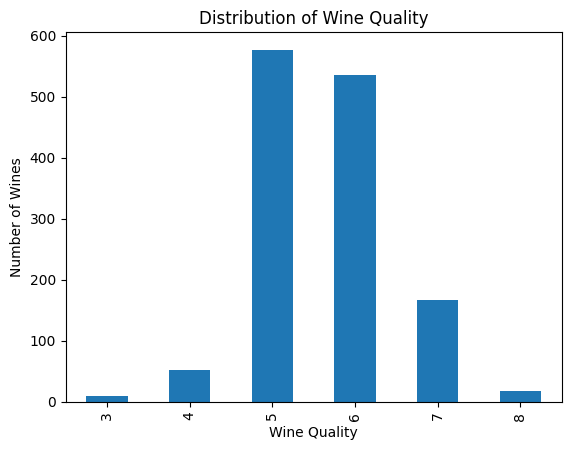

In [16]:
df["quality"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Wine Quality")
plt.ylabel("Number of Wines")
plt.title("Distribution of Wine Quality")
plt.show()

### Insight:
Most wines have a quality rating of 5 or 6. Very few wines have quality ratings of 3 or 8, showing that the target variable is unevenly distributed.

## Checking all WINE features:

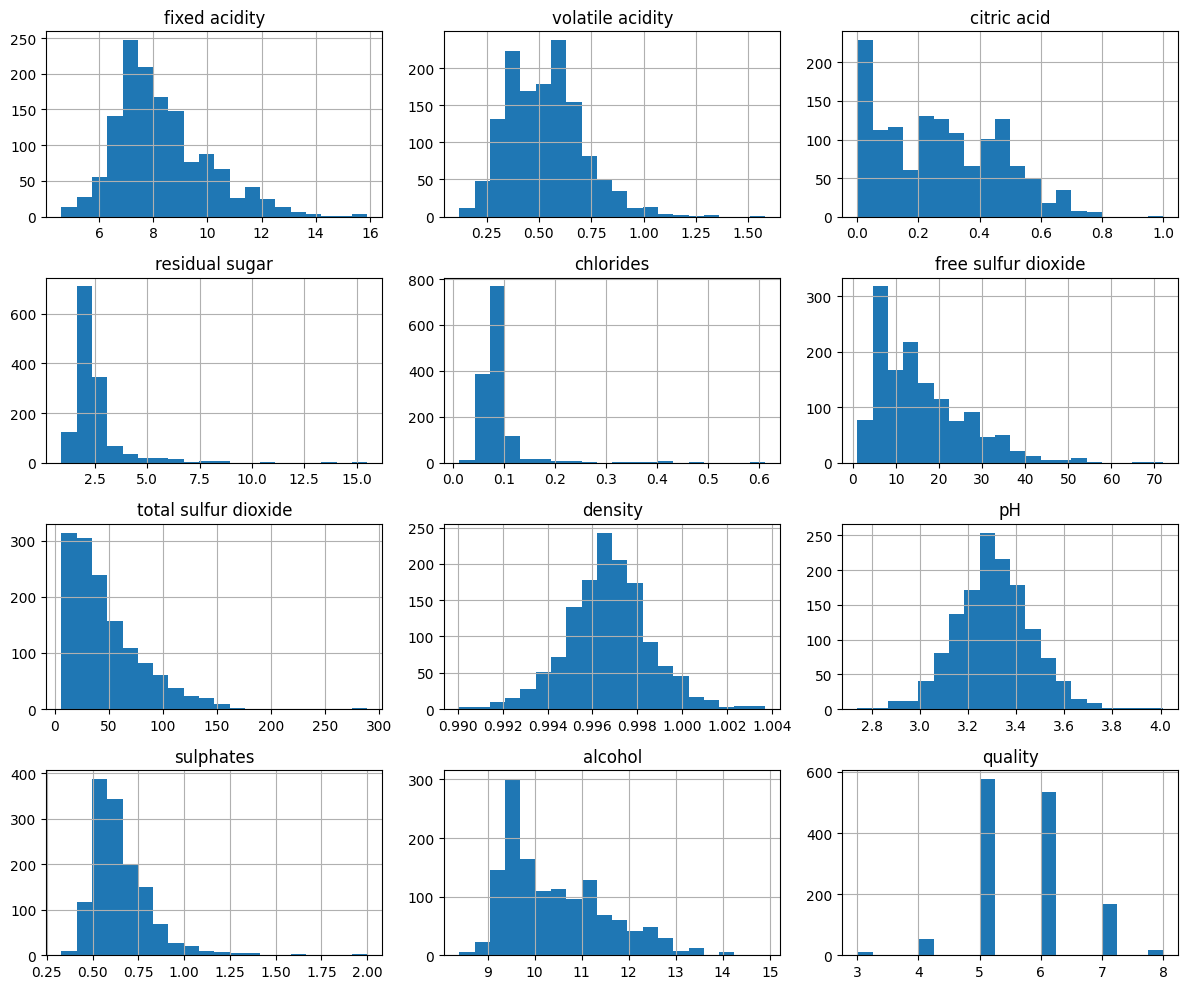

In [17]:
df.hist(figsize=(12, 10), bins=20)

plt.tight_layout()
plt.show()

# NOTABLE READING

1. Fixed Acidity: Most wines have fixed acidity around 7–9, with fewer wines having very high acidity.

2. Volatile Acidity: Most wines have volatile acidity around 0.3–0.7, with a right-skewed distribution and fewer wines having high values.

3. Citric Acid: Most wines have low citric acid levels, with the distribution decreasing as the amount increases.

4. Residual Sugar: Most wines have low residual sugar around 1–3 g/L, while a small number have much higher values.

5. Chlorides: Most wines have chloride levels around 0.05–0.10, with a small number showing much higher values.

6. Free Sulfur Dioxide: Most wines have relatively low free sulfur dioxide levels, mainly around 5–25 mg/L.

7. Total Sulfur Dioxide: Most wines have relatively low total sulfur dioxide levels, with fewer wines having very high values.

8. Density: Density is approximately normally distributed, with most values concentrated around 0.996–0.998.

9. pH: Most wines have a pH around 3.2–3.4, forming an approximately bell-shaped distribution.

10. Sulphates: Most wines have sulphate levels around 0.5–0.8, with fewer wines having higher values.

11. Alcohol: Most wines contain around 9–11% alcohol, with fewer wines having higher alcohol levels.

12. Quality: Most wines have quality ratings of 5 or 6, while very few wines have ratings of 3 or 8.

## correlation:

In [18]:
correlation = df.corr()

print(correlation["quality"].sort_values(ascending=False))

quality                 1.000000
alcohol                 0.480343
sulphates               0.248835
citric acid             0.228057
fixed acidity           0.119024
residual sugar          0.013640
free sulfur dioxide    -0.050463
pH                     -0.055245
chlorides              -0.130988
total sulfur dioxide   -0.177855
density                -0.184252
volatile acidity       -0.395214
Name: quality, dtype: float64


## notedown:
alcohol has strongest positive correlation. (0.480)
volatile acidity has strongest negative correlation. (-0.395)
others have generally weak to very weak relationships.

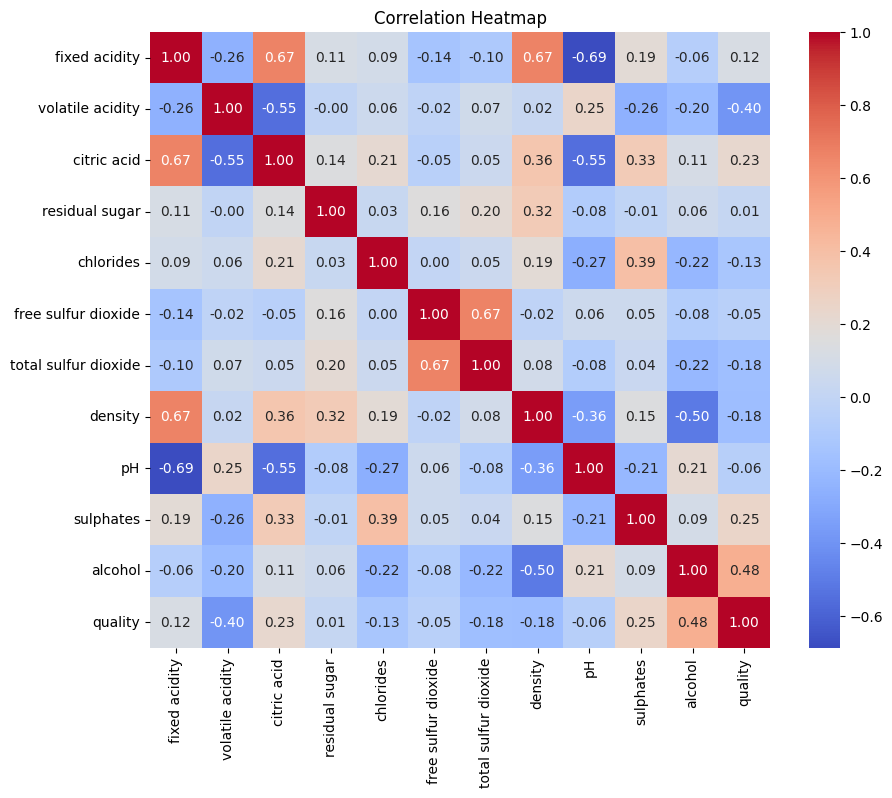

In [19]:
plt.figure(figsize=(10, 8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

### Correlation Heatmap Insights:
1. **Alcohol** has the strongest positive correlation with quality (0.48), while **volatile acidity** has the strongest negative correlation (-0.40).
2. Among the features, **fixed acidity and pH** show a strong negative correlation (-0.69), while **fixed acidity and citric acid** show a strong positive correlation (0.67).
3. **Free sulfur dioxide and total sulfur dioxide** also show a strong positive correlation (0.67).
4.  others show very weak correlation

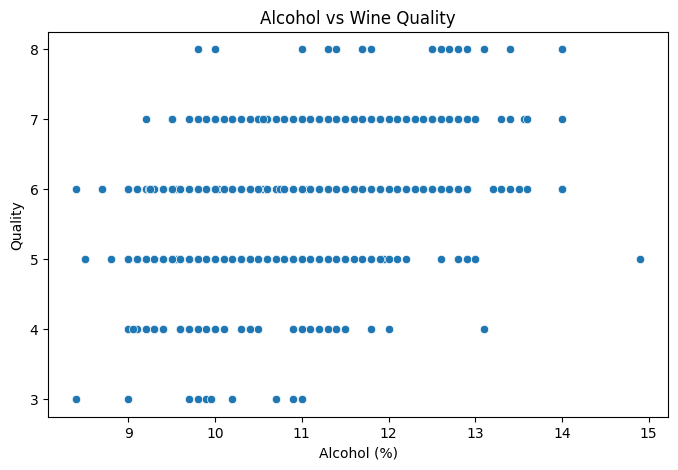

In [20]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="alcohol", y="quality")

plt.title("Alcohol vs Wine Quality")
plt.xlabel("Alcohol (%)")
plt.ylabel("Quality")
plt.show()

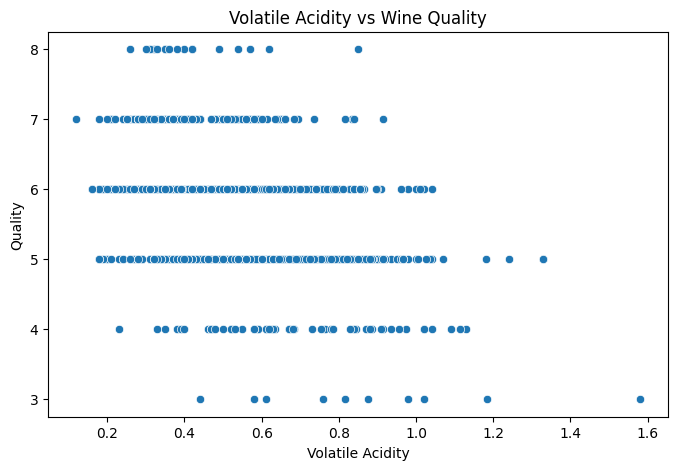

In [32]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="volatile acidity", y="quality")

plt.title("Volatile Acidity vs Wine Quality")
plt.xlabel("Volatile Acidity")
plt.ylabel("Quality")
plt.show()

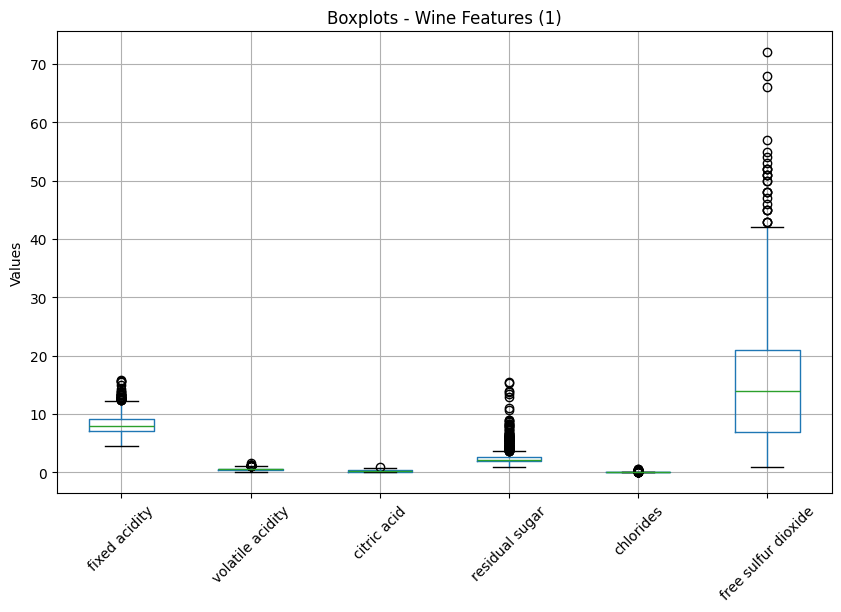

In [21]:
plt.figure(figsize=(10, 6))

features_1 = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide"]

df[features_1].boxplot()

plt.title("Boxplots - Wine Features (1)")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.show()

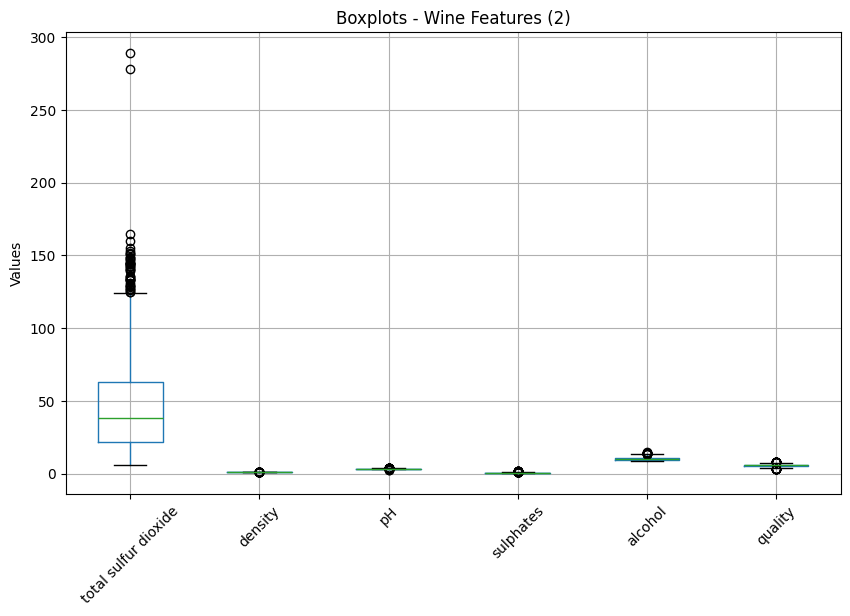

In [ ]:
plt.figure(figsize=(10, 6))

features_2 = [
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol",
    "quality"]

df[features_2].boxplot()

plt.title("Boxplots - Wine Features (2)")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.show()

# Insight:
Total sulfur dioxide, free sulfur dioxide, residual sugar, and chlorides have noticeable numbers of statistical outliers.

In [22]:
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Shape: (1359, 12)

Missing values:
0

Duplicate rows:
0

Data types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


In [40]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,5.623252
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065,0.823578
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


# EDA Report Conclusion:

The Wine Quality dataset initially contained 1599 records and 12 features. The dataset had no missing values, while 240 duplicate records were identified and removed, leaving 1359 records.

Validity and range checks did not reveal any clearly impossible values. Univariate analysis showed that most wines had quality ratings of 5 or 6. Bivariate and correlation analysis showed that alcohol had the strongest positive relationship with wine quality, while volatile acidity had the strongest negative relationship.

IQR analysis identified statistical outliers in several features. After inspecting extreme observations, no clear evidence of invalid data was found, so the outliers were retained.

Overall, the dataset was cleaned and validated and is suitable for further analysis or machine learning.

## Model Training Begins:

applying Logistic Regression

In [23]:
df.shape

(1359, 12)

In [24]:
# splitting dataset into independent and dependent variables
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [25]:
X.dtypes

fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
dtype: object

In [26]:
### train and test split:
from sklearn.model_selection import train_test_split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

#### we need to scale the input features, as they can create an imbalance in our model training, as for eg: pH and total sulfur dioxide and alcohol have different ranges.

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [45]:
model.fit(X_train_scaled, y_train)
#fit() learns the relationship between the features and the target variable
#by finding the best-fitting line that minimizes the sum
# of squared errors.
#X_train_scaled: the scaled chemical properties of the wines.
#y_train: the actual wine quality scores (3–8).

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[ 0.02,-0.19, 0.01,...,-0.06, 0.15, 0.31]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.626
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(11)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](11,)","[58.61,45.34,41.3 ,...,19.16,13.75, 7.97]"


In [46]:
print(model.coef_)
print(model.intercept_)

[ 0.0217689  -0.18745034  0.01437251 -0.0207102  -0.09289438  0.05346434
 -0.0903616  -0.01520562 -0.05648433  0.14781474  0.31012431]
5.625574977000921


In [47]:
y_pred = model.predict(X_test_scaled)

print(y_pred[:10])

[5.25818134 5.9416478  6.11423113 6.22463511 5.08504787 5.30541541
 6.01805408 5.18619598 6.56518884 6.31232891]


In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 0.5065521838274137
MSE: 0.42549946527529464
R2 Score: 0.36571593482042675


In [37]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(comparison.head(10))

      Actual  Predicted
55         5   5.245601
1291       6   5.809935
1544       7   6.368405
593        5   5.158733
1261       4   5.199286
491        7   6.776391
1004       5   5.706717
889        5   4.844757
1154       6   5.799955
824        5   5.739405


In [49]:
import numpy as np

y_pred_rounded = np.round(y_pred).astype(int)

print(y_pred_rounded[:10])

[5 6 6 6 5 5 6 5 7 6]


In [50]:
y_pred_rounded = np.clip(y_pred_rounded, 3, 8)

In [51]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_rounded)

print("Accuracy:", accuracy)

Accuracy: 0.5882352941176471


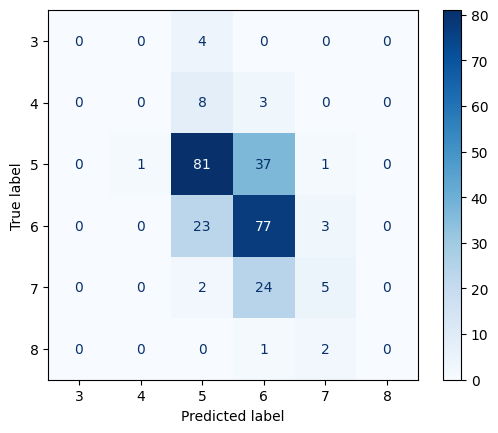

In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rounded, labels=[3, 4, 5, 6, 7, 8])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[3, 4, 5, 6, 7, 8]
)

disp.plot(cmap="Blues")
plt.show()